---
title: Transmission of Hop Powdery Mildew (*Podosphaera macularis*) in the Willamette Valley
subtitle: CS 546 Final Project -- Networks in Computational Biology
authors: 
    - Tobias Kohn
    - Trent VanHawkins
    
format:
  html:
    code-fold: true
    bibliography: BDS_546_FinalProject.bib
---

### Introduction

Pathogens displaying Long-Distance Dispersal (LDD) pose a substantial threat to global food security and agronomics. Existing agricultural managemenet practices often include treatments such as fungicide, herbicide, or pesticide; however,  airborne pathogens can readily invade across abritrary jurisdictional boundaries and propogate new infections where management practices differ. Anually, these diseases pose an estimated $220 Billion in harvest loss [@chakraborty_climate_2011]. The Willamette Valley in particular is a global leader in the production of Hops (*Humulus lupulus*) and Powdery Mildew (*Podosphaera macularis*) is a regionally important diesease which can lead to total crop loss if not managed appropriately [@ocamb_hop_2015]. The disease appeared in the Willamette Valley for the first time in 1998, and has occured in every subsequent year up until the present. As such, the hop powdery mildew pathosystem has become one of particular concern for growers and managers within the region.

Models of disease spread are a classical focus of pathology research. In recent years, however, these classical, mechanistic models have been placed into the context of spatially explicit networks, which use stochastic methods to learn network structures across discrete time transitions [@gent_prediction_2019; @ojwang_general_2021]. Letting $t$ denote time, we define a *discrete time transition* as the transiton from the disease state at $t - 1$ to time $t$. Then, we can treat classical models of auto-infection--how much disease spread at a particular unit is due to its previous infection locally-- and dispersal--how much disease is due to infection from other sourcses-- as covariate kernels in a likelihood based framework. Thus, conditioning on the disease state at $t-1$, we can try to learn the parameters associated with each kernel to predict the disease state at time $t$.

From 2014 to 2017, Hop growers in the Willamette Valley partook in an annual sentinal monitoring program for powdery mildew. Farms were surveyed monthly for the number of infected plants in each yard, the experimenatl unit, from May to July. In the present study, we aim to recreate the network structure from these disease data using the framework proposed by @pedro_inoculum_2025. An interesting feature of the proposed method is that the resulting adjasency matrix must account for the restriction illustrated by Figure 1. 

![A simple graph denoting constraints of disease spread within the resulting network.](figures/strain_contraints.png){#fig-constraints}

Briefly, each yard can grow one hop cultivar in each season -- R6 or non-R6. R6 cultivars have been genetically modified for resistance against hop powdery mildew. As often occurs, though, a strain of the disease has mutated to overcome the R6 resistance. This mutated strain is termed a "V6" pathogen, thus the disease strain can be "V6" or "non-V6". The initial disease strain was sampled at each yard at first detection each season, allowing for three different possibilities: an R6 yard with initial strain V6, a non-R6 yard with initial strain V6, or a non-R6 yard with initial strain non-V6. The case of V6 yards with initial strain non-V6 are not considered biologically meaningful (the presence of spores does not imply disease spread) and are ommitted for clarity. The restriction on our network is as follows: **non-R6 yards may only infect R6 yards if they have initial strain V6**. We elaborate on how this restriction is imposed in the methods section below. 

Clearly, this constrained, directed, and weighted adjacency matrix proposes a compelling opportunity to explore some of the analysis tools we have discussed in CS 546. In the present study, we propose to investigate the feasability and behavior of some basic tools of netowrk analysis including vertex-degree, and basic measures of vertex centrality. We then use these measures to create a descriptive profile of important yards for disease transimission within the Willamette Valley. 

### Methods

#### The Data
Biological data were obtained from a sentinel monitoring program in which hop yards representative of the Willamette Valley production region were surveyed monthly from April to July across the 2014–2017 growing seasons. Disease assessments recorded the incidence of plants with powdery mildew or primary infection (flag shoots) across 8–10 farms per year, all within Marion County, Oregon. Following data cleaning, usable records were available for 99, 113, 116, and 122 yards in 2014, 2015, 2016, and 2017, respectively. Full details of the sampling and assessment methodology are provided in @pedro_inoculum_2025. 

At first detection of powdery mildew in a given yard each season, the infecting strain was characterized as either V6-virulent or non-V6-virulent via bioassay. This distinction is critical because P. macularis strains differ in their ability to cause disease on hop cultivars carrying the R6 resistance gene: non-V6-virulent strains cannot infect R6 cultivars, while V6-virulent strains can infect both R6 and non-R6 cultivars. This strain classification directly informs the network constraints described in the Introduction and elaborated upon in the Methods below.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  149k  100  149k    0     0   422k      0 --:--:-- --:--:-- --:--:--  423k


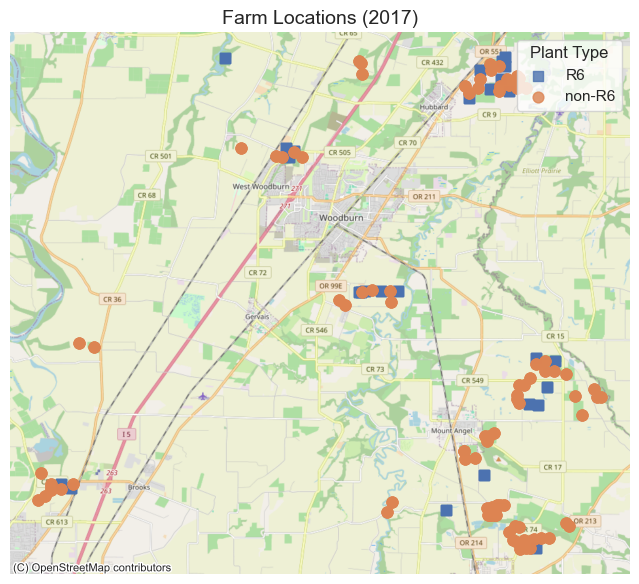

In [158]:
#| label: fig-farm-locations
#| fig-cap: "Farm locations in 2017, colored by plant type."

import scipy
import cairo
import igraph as ig
import networkx as nx
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point
from typing import Any

pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 150)

#Read in the metadata
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/data/processed/clean_summary.csv -o clean_summary.csv
meta = pd.read_csv('clean_summary.csv', index_col=0, header=0)

! rm clean_summary.csv
meta["date"] = pd.to_datetime(meta["date"])

meta_2017 = meta[meta["year"] == 2017].copy()
meta_2017["centroid_lat"] = meta_2017.groupby("field_id")["centroid_lat"].transform("first")
meta_2017["centroid_long"] = meta_2017.groupby("field_id")["centroid_long"].transform("first")
meta_2017 = meta_2017.reset_index(drop=True)

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    meta_2017,
    geometry=[Point(xy) for xy in zip(meta_2017["centroid_long"], meta_2017["centroid_lat"])],
    crs="EPSG:4326"
).to_crs(epsg=3857)  # reproject for contextily basemap

# Marker shapes per plant type
markers = {pt: m for pt, m in zip(gdf["plant_type"].unique(), ["o", "s", "^", "D", "v"])}

fig, ax = plt.subplots(figsize=(8, 6))

for plant_type, group in gdf.groupby("plant_type"):
    group.plot(
        ax=ax,
        marker=markers[plant_type],
        markersize=60,
        label=plant_type,
        alpha=0.8
    )

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Farm Locations (2017)", fontsize=14)
ax.legend(title="Plant Type", loc="upper right")
ax.set_axis_off()

plt.tight_layout()
plt.show()

#### Constructing the adjacency matrix
Letting $y_{i,t}$ denote the number of diseased plants at yard $i$ and time $t$, we assume that $y_{i, t}, \ldots, y_{n, t}$ are conditionally independent Binomial random variables with parameters $M$ for the number of plants sampled at yard $i$ and $p$ for the probability of a given plant having the disease. We can then model $p_t$ using a non-linear geralized regression model with a logit link as 

$$
\log\left(\frac{p_{i,t}}{1-p_{i,t}}\right) = \beta + \delta\underbrace{\left(\frac{\tilde{y}_i}{n_{\tilde{y}_i}}e^{-\eta_1 s_i}\right)}_{\text{auto-infection}} + \gamma \underbrace{\sum_{j \neq i} \left(\frac{a_j z_j}{n_{z_j}} e^{-\eta_2 s_j} w_{ij} (1 + d_{ij})^{-\alpha} \right)}_{\text{cross-infection}}
$$

where covariates are interpreted as in @tbl-covariates and parameters as in @tbl-parameters. Maximum Likelihood Estimates (MLEs) were obtained for each of the parameters using numerical approximation methods as described in @pedro_inoculum_2025. To allow for the restriction proposed previously, parameters were estimated separately for R6 and non-R6 yards. 


: Covariate notations and descriptions. {#tbl-covariates}

| Covariate | Description |
|-----------|-------------|
| $\tilde{y}_i$ | Number of diseased plants at yard $i$ in the prior month |
| $n_{\tilde{y}_i}$ | Number of plants sampled at yard $i$ in the prior month |
| $a_i$ | Area (hectares) of yard $i$ |
| $z_j$ | Number of diseased plants at yard $j$ in the prior month |
| $n_{z_j}$ | Number of plants sampled at yard $j$ in the prior month |
| $a_j$ | Area (hectares) of yard $j$ |
| $D_{ij}$ | Distance (kilometers) from centroids of yard $i$ to yard $j$ |
| $w_{ij}$ | Wind vector on $j - i$ direction in the prior month |
| $s_i$ | Number of fungicide sprays in yard $i$ in prior month |
| $t_j$ | Number of fungicide sprays in yard $j$ in prior month |

: Model parameters and descriptions. {#tbl-parameters}

| Parameter | Description |
|-----------|-------------|
| $\beta$ | Baseline log-odds of disease, after accounting for autoinfection and dispersal. |
| $\delta$ | Change in log-odds of disease associated with autoinfection at the yard scale, after accounting for disease spread. |
| $\gamma$ | Distance-adjusted change in log-odds of disease associated with disease spread from other yards, after accounting for autoinfection. |
| $\alpha$ | Dispersal parameter providing distance adjustment to change in log-odds of disease associated with individual source yards. |
| $\eta_1$ | Change in log-odds of disease associated with autoinfection at the yard scale, after accounting for fungicide sprays. |
| $\eta_2$ | Dispersal parameter providing fungicide spray adjustment to change in log-odds of disease associated with individual source yards. |

*Descriptions of model parameters and covariates notations for each yard of interest $i = 1,2,...,N$ in a month, and all other yards $j = 1,2,...,M_i$ relative to yard $i$.*

Once the MLEs are obtained, the weighted edge from source yard $j$ to target yard $i$ is obtained as 

$$
A_{ij} = \begin{cases} 
\gamma_1 \frac{a_j z_j}{n_{z_j}} e^{-\eta_{21} s_j} w_{ji} (1 + D_{ij})^{-\alpha_1} \cdot \mathbb{1}_{V6}(j) & \text{Yard $i$ is R6} \\
\gamma_2 \frac{a_j z_j}{n_{z_j}} e^{-\eta_{22} s_j} w_{ji} (1 + D_{ij})^{-\alpha_2} & \text{Yard $i$ is non-R6}
\end{cases}
$$

That is, the edge-weight depends on both the plant type (R6 or non-R6) of yard $i$ and the initial strain (V6 or non-V6) at yard $j$ as depicted in Figure 1. 

#### Analysis of Yard Importance

Once we obtained the adjacency matrix $A$, we computed the out-degree and out-going 
Katz centrality for each yard. Considering that $a_{ij}$ denotes the edge weight 
for disease transmission from yard $j$ to yard $i$, we computed in- and out-degree, 
respectively, as:

$$
k_i^{(\text{in})} = \sum_j a_{ij} \quad \text{and} \quad k_j^{(\text{out})} = \sum_i a_{ij}
$$

We then examined the degree distribution for both in- and out-degree to test whether 
it follows a power law above some threshold $k_{\min}$. Specifically, we tested whether 
the probability mass function takes the form:

$$
p(k) = \frac{\hat{\tau} - 1}{k_{\min}}\left(\frac{k}{k_{\min}}\right)^{-\hat{\tau}}, \quad k \geq k_{\min}
$$

where $\hat{\tau}$ is the MLE of the scaling exponent and $k_{\min}$ is estimated via 
KS-statistic minimization following @clauset_power-law_2009 as implemented in the `power_law_fit` method in `iGraph` and assess the goodness-of-fit using its inherint bootstrap approach. 

In addition to in- and out-degree for each yard, we compute the **Katz centrality** for each yard. We specifically chose Katz centrality as it assigns a baseline centrality to all nodes regardless of connectivity -- a desirable property in a sparse disease network. Katz centrality for yard $i$ is defined as

$$
\mathbf{x} = \rho \mathbf{A}\mathbf{x} + \mathbf{1} \implies \mathbf{x} = (\mathbf{I} - \rho \mathbf{A})^{-1} \cdot \mathbf{1}
$$

The free parameter $\rho$ controls the contribution of the eigenvector, and is subject to the constraint that $\rho < \kappa_1^{-1}$ where $\kappa_1$ is the spectral radius of $\mathbf{A}$. We adopt the convention of PageRank centrality and set $\rho = \frac{0.85}{\kappa_1}$. As we are most interested in the yards that are important for *spreading* disease, we compute Katz centrality for outgoing edges only. We present ranked Katz centrality for each month in visual and tabular formats.



### Results

In [159]:
#| output: false

# Read in the adjacency matrices from the CSV files
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_apr_may.csv -o network_apr_may.csv
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_may_jun.csv -o network_may_jun.csv
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/reports/networks/network_jun_jul.csv -o network_jun_jul.csv
apr_may = pd.read_csv('network_apr_may.csv', index_col=0, header=0)
may_jun = pd.read_csv('network_may_jun.csv', index_col=0, header=0)
jun_jul = pd.read_csv('network_jun_jul.csv', index_col=0, header=0)

#Read in the metadata
!curl -L https://raw.githubusercontent.com/hawktre/CS_546_FinalProject/refs/heads/main/data/processed/clean_summary.csv -o clean_summary.csv
meta = pd.read_csv('clean_summary.csv', index_col=0, header=0)

! rm clean_summary.csv
! rm network_apr_may.csv
! rm network_may_jun.csv
! rm network_jun_jul.csv


#Write a function to build an igraph with metadata
def build_graph(adj_df, meta_df):
    # Build graph
    g = ig.Graph.Weighted_Adjacency(adj_df.to_numpy().transpose(), mode="directed", attr="weight", loops=False)
    
    # Add node names
    g.vs["name"] = adj_df.columns.tolist()
    
    # Add metadata attributes
    meta_indexed = meta_df.set_index("field_id")
    for col in meta_indexed.columns:
        g.vs[col] = [meta_indexed.loc[int(v["name"]), col] for v in g.vs]
    
    return g

#clean up the metadata so that there is one row per field_id
meta_2017_clean = meta_2017[["field_id", "initial_strain", "plant_type", "centroid_lat", "centroid_long"]].drop_duplicates().reset_index(drop=True)
apr_may_g: ig.Graph = build_graph(apr_may, meta_2017_clean)
may_jun_g: ig.Graph= build_graph(may_jun, meta_2017_clean)
jun_jul_g: ig.Graph= build_graph(jun_jul, meta_2017_clean)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 67020  100 67020    0     0   248k      0 --:--:-- --:--:-- --:--:--  248k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 73431  100 73431    0     0   267k      0 --:--:-- --:--:-- --:--:--  267k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  104k  100  104k    0     0   349k      0 --:--:-- --:--:-- --:--:--  349k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  149k  100  149k    0     0   723k      0 --:--:-- --:--:-- --:--:--     0-  725k


Some summary statistics of the disease network are provided in @tbl-network-summary. There were 27 R6 yards and 95 non-R6 yards included in the 2017 study for a toal of 122 yards. As expected, infections were lowest in April ($\approx 3\%$ of yards infected) and highest in July with 44\% of R6 yards and 30% of non-R6 yards. Anecdotally, it appears that the disease spread fastest during the transiton from June to July. Farmers roughly increased the number of fungicide sprays as the disease progressed, but they seem not to differ between R6 and non-R6 yards. 

In [160]:
#| label: tbl-network-summary
#| tbl-cap: "Summary of network statistics for each month."

# Compute out-strength (weighted out-degree) for each graph
out_apr_may = np.array(apr_may_g.strength(mode = "out", weights="weight"))
out_may_jun = np.array(may_jun_g.strength(mode = "out", weights="weight"))
out_jun_jul = np.array(jun_jul_g.strength(mode = "out", weights="weight"))

# Compute in-strength (weighted in-degree) for each graph
in_apr_may = np.array(apr_may_g.strength(mode = "in", weights="weight"))
in_may_jun = np.array(may_jun_g.strength(mode = "in", weights="weight"))
in_jun_jul = np.array(jun_jul_g.strength(mode = "in", weights="weight"))

# Print a summary of the metadata
meta_2017.groupby(["date", "plant_type"]).agg(
    mean_sprays = ("sprays", "mean"),
    mean_incidence=("mildew_incidence", "mean"),
    max_incidence=("mildew_incidence", "max"),
    std_incidence=("mildew_incidence", "std"),
    number_infected=("mildew_incidence", lambda x: (x > 0).sum()),
    total_fields=("mildew_incidence", "count"),
    pct_infected=("mildew_incidence", lambda x: (x > 0).mean() * 100),
).rename(columns={
    "mean_sprays": "Mean Sprays",
    "mean_incidence": "Mean Incidence",
    "max_incidence": "Max Incidence",
    "std_incidence": "Std Incidence",
    "number_infected": "# Infected",
    "total_fields": "Total Fields",
    "pct_infected": "% Infected"
})

Mean Sprays  Mean Incidence  Max Incidence  \
date       plant_type                                               
2017-04-01 R6             0.000000        0.000185         0.0050   
           non-R6         0.000000        0.000053         0.0025   
2017-05-01 R6             0.333333        0.000093         0.0025   
           non-R6         0.442105        0.000263         0.0125   
2017-06-01 R6             1.666667        0.006852         0.0450   
           non-R6         1.442105        0.010000         0.3700   
2017-07-01 R6             2.333333        0.065556         0.5050   
           non-R6         2.263158        0.032825         0.9000   

                       Std Incidence  # Infected  Total Fields  % Infected  
date       plant_type                                                       
2017-04-01 R6               0.000962           1            27    3.703704  
           non-R6           0.000361           2            95    2.105263  
2017-05-01 R6               0.000481           1            27    3.703704  
           non-R6           0.001434           5            95    5.263158  
2017-06-01 R6               0.012569          10            27   37.037037  
           non-R6           0.050218          11            95   11.578947  
2017-07-01 R6               0.130224          12            27   44.444444  
           non-R6           0.130797          29            95   30.526316

We examined the in- and out-degree distributions for each time transition as in @fig-degree-distributions and tested whether the empirical distributions follow a power-law (@tbl-power-law-params). We reject the null-hypothesis that in-degree follows a power-law distribution for the May-June transitons (p = 0.0032), but have insufficient evidence to reject for the remiaing transitions for both in- and out-degree. We note, however, that some of these conclusions are drawn from few observations due to the sparse nature of the network. 


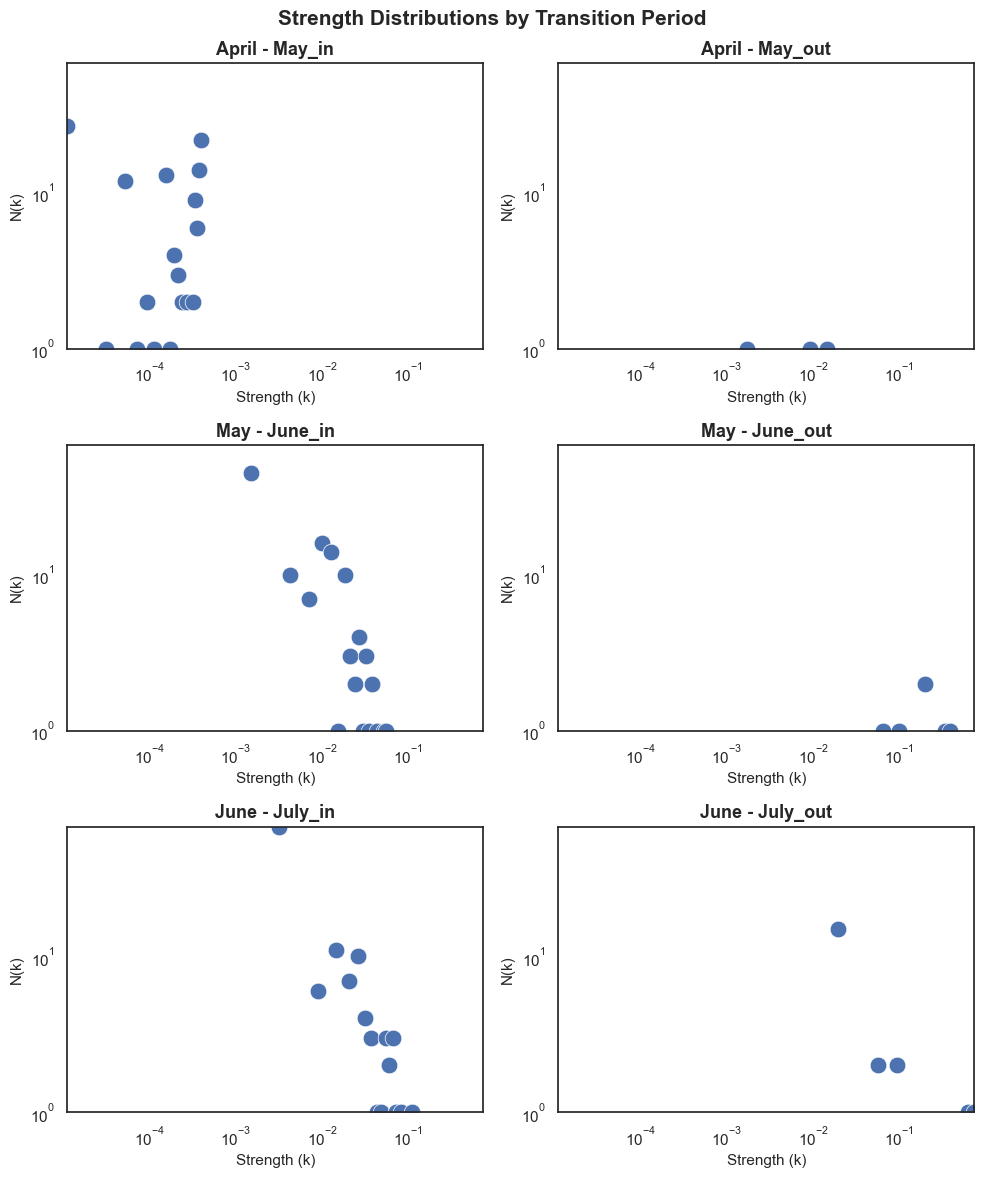

In [161]:
#| label: fig-degree-distributions
#| fig-cap: "Strength distributions for in- and out-strength across transition periods."

import seaborn as sns

def strength_distribution(graph: ig.Graph, name: str = "", bins: int = 20) -> list[dict[str, Any]]:
    """Compute strength distributions and power law fits for in- and out-strength."""

    # Compute weighted in- and out-strength for every node
    in_d = np.array(graph.strength(mode="in", weights="weight"))
    out_d = np.array(graph.strength(mode="out", weights="weight"))

    ret = []
    modes = ["in", "out"]

    for m, strength in zip(modes, [in_d, out_d]):

        # Drop nodes with zero strength (disconnected in this direction)
        strength = strength[strength > 0]

        # Bin the strengths and compute bin midpoints for plotting
        y, edges = np.histogram(strength, bins=bins)
        x = 0.5 * (edges[:-1] + edges[1:])

        # Filter out empty bins (log-log plots can't handle zeros)
        i = y > 0

        # Fit a power law to the strength distribution
        result = ig.statistics.power_law_fit(strength)

        ret.append({
            "name": f"{name}_{m}",
            "alpha": result.alpha,   # power law exponent
            "k_min": result.xmin,    # minimum value used in fit
            "p_value": result.p,     # goodness-of-fit p-value
            "x": x[i],               # bin midpoints (non-empty bins only)
            "y": y[i]                # bin counts (non-empty bins only)
        })

    return ret

# Compute strength distributions for each transition period
deg_distributions = []
graphs = [apr_may_g, may_jun_g, jun_jul_g]
names = ["April - May", "May - June", "June - July"]

for graph, name in zip(graphs, names):
    deg_distributions += strength_distribution(graph, name=name)

n = len(deg_distributions)
deg_distributions_df = pd.DataFrame(deg_distributions)

# Compute shared axis limits across all panels for comparability
all_x = np.concatenate(deg_distributions_df["x"].values)
all_y = np.concatenate(deg_distributions_df["y"].values)
x_lim = (all_x.min(), all_x.max())
y_lim = (all_y.min(), all_y.max())

# Plot all distributions in a grid, sharing axis limits across panels
sns.set_theme(style="white")
fig, axs = plt.subplots(n // 2, 2, figsize=(10, 12))
axs = axs.flatten()

for i, (ax, (_, row)) in enumerate(zip(axs, deg_distributions_df.iterrows())):
    ax.loglog(row["x"], row["y"], "o",
              markersize=12, markeredgewidth=0.5, markeredgecolor="white")
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_xlabel("Strength (k)", fontsize=11)
    ax.set_ylabel("N(k)", fontsize=11)
    ax.set_title(row["name"], fontsize=13, fontweight="bold")

# Hide unused subplots if n is odd
for ax in axs[n:]:
    ax.set_visible(False)

plt.suptitle("Strength Distributions by Transition Period", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [162]:
#| label: tbl-power-law-params
#| tbl-cap: "Power law fit parameters for strength distributions."
# Display power law fit parameters
deg_distributions_df[["name", "alpha", "k_min", "p_value"]].rename(columns={
    "name": "Transition Period (Type)",
    "alpha": "Power Law Exponent (tau)",
    "k_min": "Minimum Strength (k_min)",
    "p_value": "p-value"
})

,Transition Period (Type),Power Law Exponent (tau),Minimum Strength (k_min),p-value
0,April - May_in,49.711904,0.000389,0.2348
1,April - May_out,3.099033,0.009252,0.1960
2,May - June_in,2.467547,0.008379,0.0028
3,May - June_out,3.470326,0.201261,0.1028
4,June - July_in,2.841434,0.022836,0.0508
5,June - July_out,1.544592,0.004065,0.3524


We computed in- and out-going Katz centrality for each field at each distinct transition, setting $\rho = \frac{0.9}{\kappa_1}$ and $\beta = 1$ where $\kappa_1$ is the maximum eigenvalue associated with the relevant weighted adjacency matrix. The top 10 yards for in- and out-going centralities are showin in @tbl-katz-centrality-in and @tbl-katz-centrality-out, respectively.

In [163]:
#| label: tbl-katz-centrality-in
#| tbl-cap: "Top 10 nodes by Katz in-centrality across all transition periods, with metadata attributes."

#Function to compute spectral radius of an adjacency matrix
def spectral_radius(adj_matrix: np.ndarray):
    #Get eigenvalues
    eigenvalues = np.linalg.eigvals(adj_matrix)
    #return the maximum absolute value
    return np.max(np.abs(eigenvalues))

#Function to compute Katz centrality given an adjacency matrix and alpha parameter
def katz_centrality(adj_matrix: np.ndarray, alpha: float, out = True):
    #Number of nodes
    n = adj_matrix.shape[0]
    
    #Identity matrix of appropriate size
    I = np.eye(n)
    
    #Transpose if calculating out-centrality
    if out:
        adj_matrix = adj_matrix.T
    
    #Compute Katz centrality using the formula: (I - alpha * A^T)^(-1)
    centrality = np.linalg.solve(I - alpha * adj_matrix, np.ones(n))
    
    return centrality

#Compute alpha for each transition
a_apr_may = 0.01 / spectral_radius(apr_may)
a_may_jun = 0.01 / spectral_radius(may_jun)
a_jun_jul = 0.01 / spectral_radius(jun_jul)

#Compute Katz centrality for in- and out-centrality for each transition
## April - May
katz_out_apr_may = pd.DataFrame(katz_centrality(apr_may, a_apr_may), columns=["katz"], index=labels).sort_values("katz", ascending=False)
katz_in_apr_may = pd.DataFrame(katz_centrality(apr_may, a_apr_may, out=False), columns=["katz"], index=labels).sort_values("katz", ascending=False)

## May - June
katz_out_may_jun = pd.DataFrame(katz_centrality(may_jun, a_may_jun), columns=["katz"], index=labels).sort_values("katz", ascending=False)
katz_in_may_jun = pd.DataFrame(katz_centrality(may_jun, a_may_jun, out=False), columns=["katz"], index=labels).sort_values("katz", ascending=False)

## June - July
katz_out_jun_jul = pd.DataFrame(katz_centrality(jun_jul, a_jun_jul), columns=["katz"], index=labels).sort_values("katz", ascending=False)
katz_in_jun_jul = pd.DataFrame(katz_centrality(jun_jul, a_jun_jul, out=False), columns=["katz"], index=labels).sort_values("katz", ascending=False)

# Merge Katz centrality results with metadata to get field attributes for top-ranked nodes
## April - May
katz_in_apr_may = katz_in_apr_may.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_in_apr_may["group"] = katz_in_apr_may["initial_strain"] + " | " + katz_in_apr_may["plant_type"]
katz_in_apr_may = katz_in_apr_may.drop_duplicates()

katz_out_apr_may = katz_out_apr_may.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_out_apr_may["group"] = katz_out_apr_may["initial_strain"] + " | " + katz_out_apr_may["plant_type"]
katz_out_apr_may = katz_out_apr_may.drop_duplicates()
## May - June
katz_in_may_jun = katz_in_may_jun.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_in_may_jun["group"] = katz_in_may_jun["initial_strain"] + " | " + katz_in_may_jun["plant_type"]
katz_in_may_jun = katz_in_may_jun.drop_duplicates()

katz_out_may_jun = katz_out_may_jun.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_out_may_jun["group"] = katz_out_may_jun["initial_strain"] + " | " + katz_out_may_jun["plant_type"] 
katz_out_may_jun = katz_out_may_jun.drop_duplicates()

## June - July
katz_in_jun_jul = katz_in_jun_jul.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_in_jun_jul["group"] = katz_in_jun_jul["initial_strain"] + " | " + katz_in_jun_jul["plant_type"]
katz_in_jun_jul = katz_in_jun_jul.drop_duplicates()

katz_out_jun_jul = katz_out_jun_jul.merge(meta_2017[["field_id", "initial_strain", "plant_type"]], how="left", left_on="field_id", right_on="field_id")
katz_out_jun_jul["group"] = katz_out_jun_jul["initial_strain"] + " | " + katz_out_jun_jul["plant_type"]     
katz_out_jun_jul = katz_out_jun_jul.drop_duplicates()

# Merge them all into a single DataFrame for easier comparison
katz_in_apr_may["transition"] = "April - May"
katz_in_apr_may["direction"] = "In-Centrality"
katz_out_apr_may["transition"] = "April - May"
katz_out_apr_may["direction"] = "Out-Centrality"

katz_in_may_jun["transition"] = "May - June"
katz_in_may_jun["direction"] = "In-Centrality"
katz_out_may_jun["transition"] = "May - June"
katz_out_may_jun["direction"] = "Out-Centrality"

katz_in_jun_jul["transition"] = "June - July"
katz_in_jun_jul["direction"] = "In-Centrality"
katz_out_jun_jul["transition"] = "June - July"
katz_out_jun_jul["direction"] = "Out-Centrality"

katz_all = pd.concat([katz_in_apr_may, katz_out_apr_may, katz_in_may_jun, katz_out_may_jun, katz_in_jun_jul, katz_out_jun_jul], ignore_index=True)

#Pivot wider to have separate columns for in- and out-centrality
katz_pivot = katz_all.pivot_table(index=["field_id", "initial_strain", "plant_type", "group", "transition"], columns="direction", values="katz").reset_index()
katz_pivot.columns.name = None  # remove the aggregation name
katz_pivot.drop_duplicates().sort_values(["In-Centrality"], ascending=[False]).head(10)

,field_id,initial_strain,plant_type,group,transition,In-Centrality,Out-Centrality
240,86,non-V6,non-R6,non-V6 | non-R6,April - May,1.192425,1.0
117,42,non-V6,non-R6,non-V6 | non-R6,April - May,1.191823,1.0
108,39,non-V6,non-R6,non-V6 | non-R6,April - May,1.191673,1.0
237,85,non-V6,non-R6,non-V6 | non-R6,April - May,1.191640,1.0
114,41,non-V6,non-R6,non-V6 | non-R6,April - May,1.190917,1.0
111,40,non-V6,non-R6,non-V6 | non-R6,April - May,1.190917,1.0
96,35,V6,non-R6,V6 | non-R6,April - May,1.190721,1.0
99,36,non-V6,non-R6,non-V6 | non-R6,April - May,1.190498,1.0
102,37,non-V6,non-R6,non-V6 | non-R6,April - May,1.190471,1.0
105,38,V6,non-R6,V6 | non-R6,April - May,1.190194,1.0


In [164]:
#| label: tbl-katz-centrality-out
#| tbl-cap: "Top 10 nodes by Katz out-centrality across all transition periods, with metadata attributes."

katz_pivot.sort_values(["Out-Centrality"], ascending=[False]).head(10)

,field_id,initial_strain,plant_type,group,transition,In-Centrality,Out-Centrality
81,30,V6,R6,V6 | R6,April - May,1.000847,8.089529
342,127,V6,non-R6,V6 | non-R6,April - May,1.014270,5.356912
30,12,V6,non-R6,V6 | non-R6,April - May,1.171438,1.654007
176,63,V6,non-R6,V6 | non-R6,May - June,1.000115,1.521764
29,11,V6,non-R6,V6 | non-R6,May - June,1.012548,1.456352
175,63,V6,non-R6,V6 | non-R6,June - July,1.001395,1.453562
61,22,V6,non-R6,V6 | non-R6,June - July,1.004646,1.367883
65,24,V6,non-R6,V6 | non-R6,May - June,1.004348,1.272332
281,100,V6,R6,V6 | R6,May - June,1.033005,1.264882
32,12,V6,non-R6,V6 | non-R6,May - June,1.024011,1.130825


Perhaps a better way to interpret these values is in the context of their spatial nature. Spatial plots of the network are given in @fig-spatial-network. The plots show only edge-weights above the 90th percentile, and the color of individual points indicates the relative out-going Katz centrality. From this plot, we see that relatively few farms are responsible for the majority of disease transmission within this network. From @tbl-katz-centrality-out, we can see that these yards have field id 30, 127, 12, 63, 11, and 22. Out-going centrality is the largest during the April-May transition. 

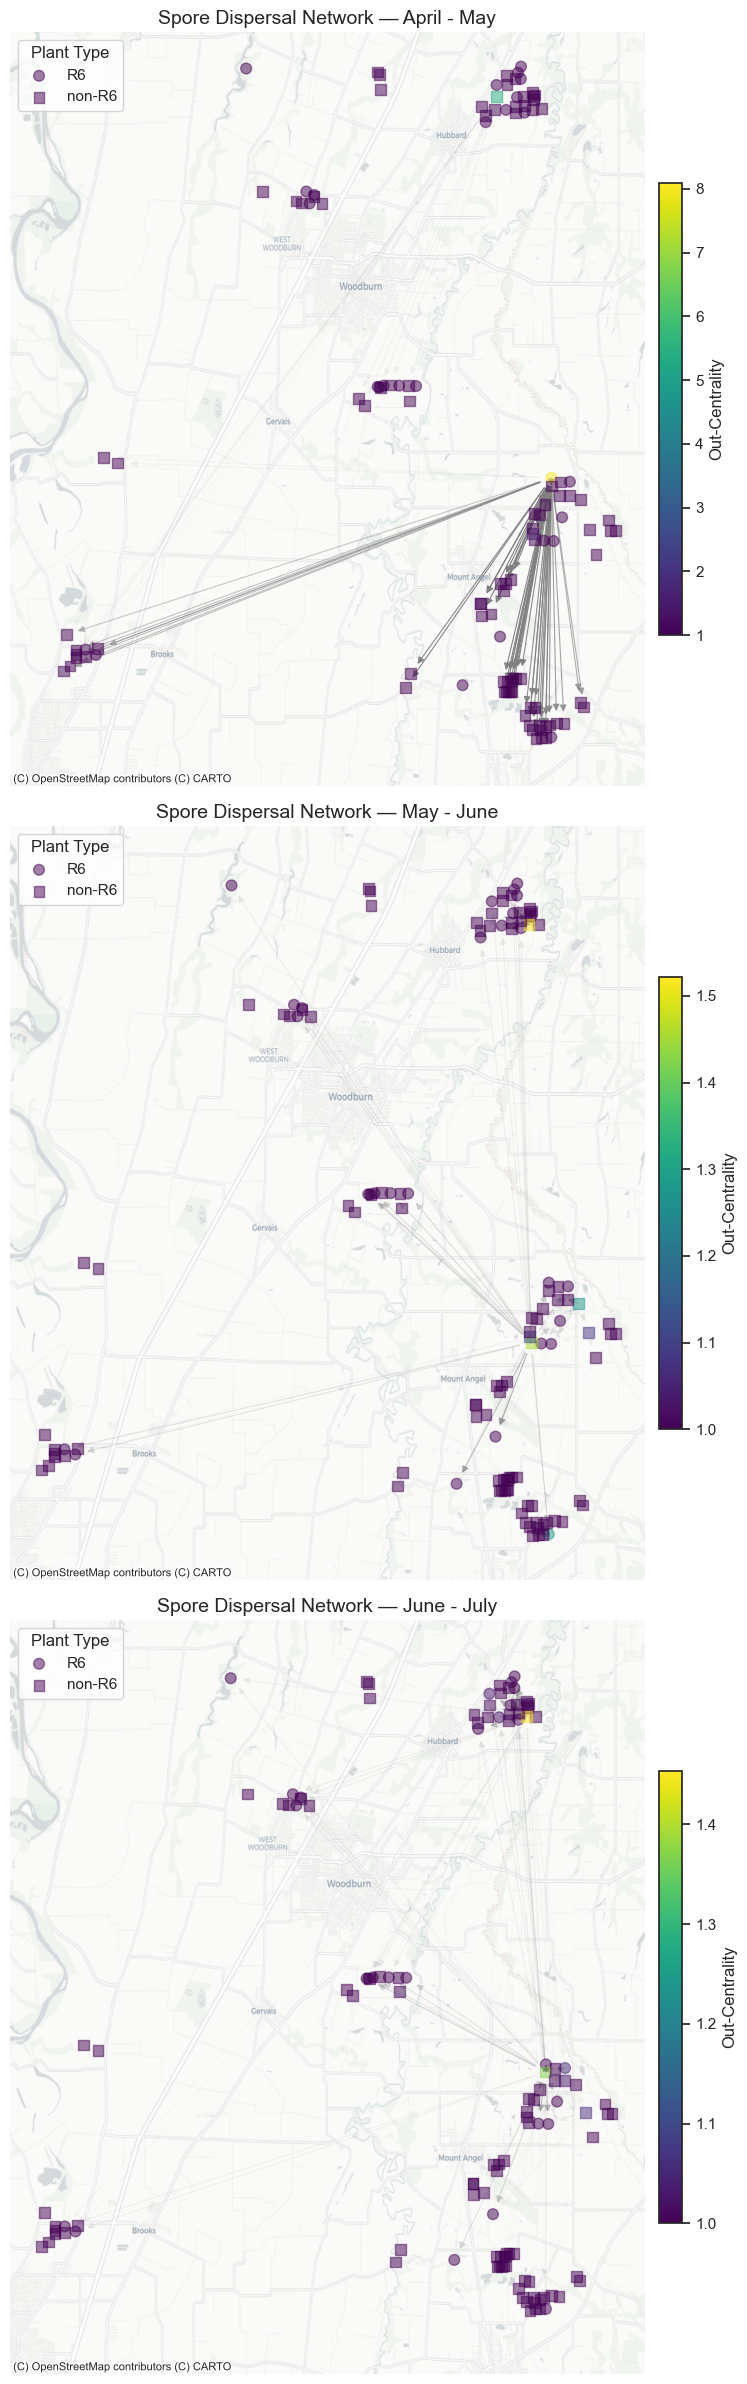

In [165]:
#| label: fig-spatial-network
#| fig-cap: "Spatial network visualization for each transition period, with node colors representing out-centrality and edge transparency representing connection strength."
def plot_spatial_network(graph: ig.Graph, 
                         katz_df: pd.DataFrame,
                         transition: str,
                         edge_quantile: float = 0.90,
                         node_size: int = 60,
                         ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # --- Filter katz_df to this transition period ---
    katz_transition = katz_df[katz_df["transition"] == transition].drop_duplicates(subset="field_id")

    # --- Extract node attributes from igraph ---
    node_df = pd.DataFrame({
        "field_id": [int(v["name"]) for v in graph.vs],
        "centroid_lat": [v["centroid_lat"] for v in graph.vs],
        "centroid_long": [v["centroid_long"] for v in graph.vs],
        "plant_type": [v["plant_type"] for v in graph.vs],
    }).merge(katz_transition[["field_id", "In-Centrality", "Out-Centrality"]], 
             on="field_id", how="left")

    # Normalize Out-Centrality tofor colormap
    out_cent = node_df["Out-Centrality"].values.astype(float)
    out_cent_norm = (out_cent - out_cent.min()) / (out_cent.max() - out_cent.min() + 1e-9)
    node_df["out_cent_norm"] = out_cent_norm

    # --- Convert to Web Mercator for contextily ---
    gdf_nodes = gpd.GeoDataFrame(
        node_df,
        geometry=[Point(xy) for xy in zip(node_df["centroid_long"], node_df["centroid_lat"])],
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    pos = {row["field_id"]: (row.geometry.x, row.geometry.y) 
           for _, row in gdf_nodes.iterrows()}

    # --- Build networkx graph ---
    G = nx.DiGraph()
    G.add_nodes_from(node_df["field_id"].tolist())

    edges = [(int(graph.vs[e.source]["name"]), 
              int(graph.vs[e.target]["name"]), 
              e["weight"]) for e in graph.es]
    
    weights = np.array([w for _, _, w in edges])
    threshold = np.quantile(weights[weights > 0], edge_quantile)
    filtered_edges = [(u, v, w) for u, v, w in edges if w >= threshold]
    G.add_weighted_edges_from(filtered_edges)

    filtered_weights = np.array([w for _, _, w in filtered_edges])
    edge_alphas = (filtered_weights - filtered_weights.min()) / (filtered_weights.max() - filtered_weights.min() + 1e-9)

    # --- Colormap for Out-Centrality ---
    cmap = plt.cm.viridis
    node_colors = {row["field_id"]: cmap(row["out_cent_norm"]) 
                   for _, row in gdf_nodes.iterrows()}

    # --- Draw nodes per plant type (for marker shape legend) ---
    plant_types = sorted(gdf_nodes["plant_type"].unique())
    markers = {pt: m for pt, m in zip(plant_types, ["o", "s", "^", "D", "v"])}

    for plant_type, group in gdf_nodes.groupby("plant_type"):
        node_ids = group["field_id"].tolist()
        colors_for_group = [node_colors[n] for n in node_ids]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_ids,
            node_size=node_size,
            node_color=colors_for_group,
            node_shape=markers[plant_type],
            alpha=0.5,
            ax=ax,
            label=plant_type
        )

    # --- Draw edges ---
    edge_list = [(u, v) for u, v, _ in filtered_edges]
    for (u, v), alpha in zip(edge_list, edge_alphas):
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            alpha=float(alpha),
            edge_color="gray",
            arrows=True,
            arrowsize=10,
            width=0.8,
            ax=ax
        )

    # --- Colorbar for Out-Centrality ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=out_cent.min(), vmax=out_cent.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Out-Centrality", shrink=0.6, pad=0.02)

    # --- Basemap and styling ---
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_title(f"Spore Dispersal Network — {transition}", fontsize=14)
    ax.legend(title="Plant Type", loc="upper left")
    ax.set_axis_off()

    return ax

fig, axs = plt.subplots(3, 1, figsize=(8, 24))

for ax, (graph, transition) in zip(axs, [
    (apr_may_g, "April - May"),
    (may_jun_g, "May - June"),
    (jun_jul_g, "June - July")
]):
    plot_spatial_network(graph, katz_pivot, transition=transition, ax=ax, edge_quantile=0.8)

plt.tight_layout()
plt.show()

@tbl-katz-centrality-metadata gives some attributes for the fields with highest outgoing Katz-centrality. Interestingly, for the field with maximum centraility (Field ID: 30), the highest centrality was during the April-May transition. This event was before any fungicide had been applied to the plants. 

In [166]:
#| label: tbl-katz-centrality-metadata
#| tbl-cap: "Metadata attributes for top-ranked nodes by Katz centrality, showing potentially important fields in the spore dispersal network."
meta_2017.loc[meta_2017["field_id"].isin([30, 127, 12, 63, 11, 22]), ["field_id", "date", "initial_strain", "plant_type", "sprays", "mildew_incidence"]]

,field_id,date,initial_strain,plant_type,sprays,mildew_incidence
36,11,2017-04-01,V6,non-R6,0,0.0000
37,11,2017-05-01,V6,non-R6,0,0.0025
38,11,2017-06-01,V6,non-R6,2,0.0000
39,11,2017-07-01,V6,non-R6,3,0.0000
40,12,2017-04-01,V6,non-R6,0,0.0025
41,12,2017-05-01,V6,non-R6,0,0.0025
42,12,2017-06-01,V6,non-R6,2,0.0000
43,12,2017-07-01,V6,non-R6,3,0.0000
80,22,2017-04-01,V6,non-R6,0,0.0000
81,22,2017-05-01,V6,non-R6,0,0.0000



### Discussion
In this report, we estimated the edge-weights for the disease transmission network of Hop Powdery Mildew (*Podosphaera macularis*) in the Willamette Valley following the methods of Pedro et. al., 2026. That is, we used a likelihood-based framework that explicitly accounts for the spatial dispersal of spores as a function wind and distance during three discrete monthly time transitions from April to July, 2017. After recovering the network weights, we examined in- and out-degree distributions to assess the goodness-of-fit of a power-law to the tail of the distributions and uncovered that both in- and out-degree generally follow power-law distributions within this disease transmission network, suggesting that targeting a few important yards could serve as a beneficial treatment strategy in the future. 

An analysis of Katz centrality at each of the three time transitions confirmed that relatively few yards could be responsible for the vast majority of infections. It is likely that early, targeted intervention with fungicides at yards with a large outgoing Katz-centrality could drastically reduce transmission events. Yards with the largest Katz centrality all had V6 infections. This result makes ssnese given the constraints imposed by @fig-constraints. Yards with V6 infections can infect all other yards, while those with non-V6 infections cannot. 

This analysis is not without limitations. We first make note of the sparse nature of disease networks, which makes it difficult to effectively assess degree distribution. For example, the out-degree for some transmissions were represented entirely by 2 - 4 bins. We have also made some simplifying assumptions of this netork. For example, the assumptions displayed by @fig-constraints. In reality, the assessment of R6 resistance and V6 virulence are assessed on an ordinal scale, further complicating transmission dynamics than what is displayed by our model.  

Here, we estimated edge-weights using two seperate models, one for R6 yards and one for non-R6 yards. Conducting estimation for for two seperate sub-networks is likely a non-realistic framework and could introduce bias into parameter estimates. Thinking about this network in a multi-layer framework may pose a promising alternative to unify the two sub-networks moving forward. 